这里说频率是指一个机场航班出现的频率

## 加载数据

数据已经预处理过了

In [27]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv', dtype={'aircraft': str})

# 查看前几行数据，确保加载成功
print(data.head())

print(data.info())

         flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0  /O2MVlG1lP0=      窄体  194.0      321     3       1      2.42  102   
1  azmQzfSK1Vs=      窄体    NaN      321     3       3       NaN   31   
2  NcjJIwuZ7EM=      窄体  194.0      321     1       1      1.73  136   
3  OPrfHrOAYb4=      窄体  194.0      321     1       1      1.95  128   
4  BzH6ckq374w=      窄体  194.0      321     1       1      3.35  143   

              a             b  ...  year  month  day  weekday  hour  minute  \
0  xIqe+QQIQXQ=  AfKac4FzdXs=  ...  2024      1    1        0     7       0   
1  So/c8CkA/Xs=  AfKac4FzdXs=  ...  2024      1    1        0    15      35   
2  1/9nd1jNCE0=  /qxKZMQeBus=  ...  2024      1    1        0    17       0   
3  /qxKZMQeBus=  1/9nd1jNCE0=  ...  2024      1    1        0    19      45   
4  1/9nd1jNCE0=  grkgazDvJmY=  ...  2024      1    1        0     6      55   

   second          from            to   unit_price  
0       0  xIqe+QQIQXQ=  AfKac4FzdXs=  

## 编码分类变量

### 新增城市标签

In [28]:
import json
# 加载字典
with open('../../data-hh/my/encoder/city_labels_航班频率加权图标签.json', 'r') as file:
    city_labels_loaded = json.load(file)

print("加载的字典：", city_labels_loaded)

加载的字典： {'+3eoTOkHfoU=': 2, '0Koyk9pJc0s=': 2, '4j3sFPu6XuA=': 2, '9obCP1myMDU=': 0, 'CnmNtb5MOJA=': 0, 'CzI09pVjQzQ=': 2, 'DInJHXgQayE=': 2, 'EIsXRbFUH34=': 2, 'MSFyivV4ETI=': 2, 'N4hmDZN/CJQ=': 0, 'UO2RniR7lJ8=': 2, 'XUXDuFGVfBM=': 2, 'ZCvDTbZuS8Q=': 2, 'gK3uAaRHrOs=': 0, 'jVYRvyHjuvM=': 2, '+O1iBQtlFGU=': 0, '/M8gHzjxpNU=': 0, '0J4jz5aCatU=': 0, 'AKQNtuL5r6Q=': 0, 'AlGb30xUGAU=': 0, 'C3VfOpfT580=': 0, 'Eg2bemFsI9I=': 0, 'FWD6O2fHsIU=': 0, 'KETr2NAmAHE=': 0, 'KFsTKxkC/6g=': 0, 'Qe7TEMbQt6o=': 0, 'QyEgIt0M8Sg=': 0, 'So/c8CkA/Xs=': 0, 'XuLAnICDnIM=': 0, 'a2cXIUGpIbw=': 0, 'g1hKMyP1V8I=': 0, 'iX2Pe2pxiqQ=': 0, 'lI1bSVMW3Tg=': 0, 'mljW2xeLSiI=': 2, 'ngSgjHYUqxE=': 0, 'tKjndGSl9NQ=': 0, 'vbo2dwBOeps=': 0, 'yypkiQCX5lk=': 0, '+S5aV4Y0s8w=': 0, 'Szk6NJM5C9Y=': 0, 'hwin1ipuzwk=': 0, 'nJFTk7JNmpw=': 0, 'wSF4qXvI044=': 0, 'xIqe+QQIQXQ=': 0, 'zwVGiYamVc0=': 0, '+cjxQ01BFmw=': 0, '/qxKZMQeBus=': 0, '07fT2dsZOJM=': 0, '1/9nd1jNCE0=': 0, '2WRfpdopfDw=': 0, '3nMB4t9SNGw=': 0, '4J2zqjPuTyI=': 0, '4Li

In [29]:
# 使用 map 对 'a', 'b', 'c', 'from', 'to' 列进行标签化，新增对应的标签列
data['a_label'] = data['a'].map(city_labels_loaded)
data['b_label'] = data['b'].map(city_labels_loaded)
data['c_label'] = data['c'].map(city_labels_loaded)
data['from_label'] = data['from'].map(city_labels_loaded)
data['to_label'] = data['to'].map(city_labels_loaded)

### 新增城市二维嵌入

In [30]:
import json

# 加载字典
with open('../../data-hh/my/encoder/城市嵌入编码_航班频率加权图.json', 'r') as file:
    city_embeddings = json.load(file)

print("加载的字典：", city_embeddings)


加载的字典： {'+3eoTOkHfoU=': [-1.8774617910385132, 0.2639346420764923], '0Koyk9pJc0s=': [-2.061645984649658, 0.2378724366426468], '4j3sFPu6XuA=': [-1.9920035600662231, 0.21034681797027588], '9obCP1myMDU=': [0.3407285809516907, -0.21957316994667053], 'CnmNtb5MOJA=': [0.31837669014930725, 0.23422951996326447], 'CzI09pVjQzQ=': [-2.4111437797546387, 0.27388450503349304], 'DInJHXgQayE=': [-2.3579261302948, 0.03483475372195244], 'EIsXRbFUH34=': [-2.383272647857666, 0.2895139455795288], 'MSFyivV4ETI=': [-2.1652190685272217, -0.17630386352539062], 'N4hmDZN/CJQ=': [-0.2817063629627228, 0.14106889069080353], 'UO2RniR7lJ8=': [-2.239583969116211, 0.08994542807340622], 'XUXDuFGVfBM=': [-1.5348491668701172, 0.07484793663024902], 'ZCvDTbZuS8Q=': [-2.073256254196167, -0.04029576852917671], 'gK3uAaRHrOs=': [-0.35426580905914307, -0.46217820048332214], 'jVYRvyHjuvM=': [-1.7131704092025757, 0.21891483664512634], '+O1iBQtlFGU=': [-0.9005524516105652, 0.08231350779533386], '/M8gHzjxpNU=': [0.3819163143634796, -

In [31]:
import pandas as pd
import numpy as np

# 将 city_embeddings 转换为 DataFrame
embedding_df = pd.DataFrame.from_dict(city_embeddings, orient='index', columns=['embedding_1', 'embedding_2'])
embedding_df.index.name = 'city'

# 用 'a', 'b', 'c', 'from', 'to' 字段与 embedding_df 合并
data = data.merge(embedding_df, left_on='a', right_index=True, how='left')
data.rename(columns={'embedding_1': 'a_embedding_1', 'embedding_2': 'a_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='b', right_index=True, how='left')
data.rename(columns={'embedding_1': 'b_embedding_1', 'embedding_2': 'b_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='c', right_index=True, how='left')
data.rename(columns={'embedding_1': 'c_embedding_1', 'embedding_2': 'c_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='from', right_index=True, how='left')
data.rename(columns={'embedding_1': 'from_embedding_1', 'embedding_2': 'from_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='to', right_index=True, how='left')
data.rename(columns={'embedding_1': 'to_embedding_1', 'embedding_2': 'to_embedding_2'}, inplace=True)

# 查看添加的新列
print(data[['a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 'to_embedding_1', 'to_embedding_2']])


         a_embedding_1  a_embedding_2  b_embedding_1  b_embedding_2  \
0             0.844219       0.670595       0.247661      -0.232173   
1             0.485271      -0.768222       0.247661      -0.232173   
2             0.640395      -0.070485       0.461287      -0.782171   
3             0.461287      -0.782171       0.640395      -0.070485   
4             0.640395      -0.070485       0.497835      -0.072629   
...                ...            ...            ...            ...   
5999220       0.152204      -0.293112       0.423023      -0.517861   
5999221       0.423023      -0.517861       0.340463       0.024580   
5999222       0.340463       0.024580       0.423023      -0.517861   
5999223       0.423023      -0.517861       0.050724       0.092825   
5999224       0.050724       0.092825       0.423023      -0.517861   

         c_embedding_1  c_embedding_2  from_embedding_1  from_embedding_2  \
0             0.485271      -0.768222          0.844219          0.670

### 统计不同城市的频率

In [32]:
# 将 from 和 to 两列合并，并统计每个城市的出现次数
city_count_series = pd.concat([data['from'], data['to']]).value_counts()

# 转换为 city_count 数据框
city_count = city_count_series.reset_index()
city_count.columns = ['city', 'count']

# 3. 创建 city_map，将每个城市映射为其出现次数（或者任何你需要的值）
city_map = dict(zip(city_count['city'], city_count['count']))

# 输出结果
print(city_count)

             city   count
0    vbo2dwBOeps=  478332
1    /M8gHzjxpNU=  450316
2    gK3uAaRHrOs=  446006
3    So/c8CkA/Xs=  418933
4    0J4jz5aCatU=  408305
..            ...     ...
247  iPk6Y04ZgnI=     122
248  MgrS1LT2KO4=      91
249  DwCmftDLjPw=      62
250  wbf1sxPhwNM=      60
251  Eed3EdkMDqg=      49

[252 rows x 2 columns]


使用 json 保存和加载 city_map

In [33]:
import json

# 保存 city_map 到 JSON 文件
with open('../../data-hh/my/encoder/city_map_频率编码.json', 'w') as f:
    json.dump(city_map, f)

print("city_map_频率编码 已保存到 city_map_频率编码")

city_map_频率编码 已保存到 city_map_频率编码


### 对'a', 'b', 'c', 'from', 'to'进行频率编码

In [34]:
# 使用 city_map 替换指定列的值
columns_to_replace = ['a', 'b', 'c', 'from', 'to']

# 遍历指定列并直接用 map 映射
for col in columns_to_replace:
    data[col] = data[col].map(city_map)

# 输出结果
print(city_count)
print(data)

             city   count
0    vbo2dwBOeps=  478332
1    /M8gHzjxpNU=  450316
2    gK3uAaRHrOs=  446006
3    So/c8CkA/Xs=  418933
4    0J4jz5aCatU=  408305
..            ...     ...
247  iPk6Y04ZgnI=     122
248  MgrS1LT2KO4=      91
249  DwCmftDLjPw=      62
250  wbf1sxPhwNM=      60
251  Eed3EdkMDqg=      49

[252 rows x 2 columns]
               flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0        /O2MVlG1lP0=      窄体  194.0      321     3       1      2.42  102   
1        azmQzfSK1Vs=      窄体    NaN      321     3       3       NaN   31   
2        NcjJIwuZ7EM=      窄体  194.0      321     1       1      1.73  136   
3        OPrfHrOAYb4=      窄体  194.0      321     1       1      1.95  128   
4        BzH6ckq374w=      窄体  194.0      321     1       1      3.35  143   
...               ...     ...    ...      ...   ...     ...       ...  ...   
5999220  o+kMsWUf4Kg=      窄体  162.0      737     1       1      1.93  102   
5999221  w+GXbx7u3EM=      窄体  168.0    

### 对'flt_no', 'bd_type', 'aircraft'进行标签编码

In [35]:
data.head(5)

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,pax,a,b,...,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
0,/O2MVlG1lP0=,窄体,194.0,321,3,1,2.42,102,238768.0,29260.0,...,0.844219,0.670595,0.247661,-0.232173,0.485271,-0.768222,0.844219,0.670595,0.247661,-0.232173
1,azmQzfSK1Vs=,窄体,NaN,321,3,3,NaN,31,418933.0,29260.0,...,0.485271,-0.768222,0.247661,-0.232173,0.844219,0.670595,0.485271,-0.768222,0.844219,0.670595
2,NcjJIwuZ7EM=,窄体,194.0,321,1,1,1.73,136,161005.0,110378.0,...,0.640395,-0.070485,0.461287,-0.782171,NaN,NaN,0.640395,-0.070485,0.461287,-0.782171
3,OPrfHrOAYb4=,窄体,194.0,321,1,1,1.95,128,110378.0,161005.0,...,0.461287,-0.782171,0.640395,-0.070485,NaN,NaN,0.461287,-0.782171,0.640395,-0.070485
4,BzH6ckq374w=,窄体,194.0,321,1,1,3.35,143,161005.0,152428.0,...,0.640395,-0.070485,0.497835,-0.072629,NaN,NaN,0.640395,-0.070485,0.497835,-0.072629


In [36]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
# categorical_columns = ['flt_no', 'bd_type', 'aircraft', 'a', 'b', 'c', 'from', 'to']
categorical_columns = ['flt_no', 'bd_type', 'aircraft']

# 创建并应用 LabelEncoder
label_encoders = {}

# 创建保存编码器的文件夹（如果文件夹不存在）
save_folder = '../../data-hh/my/encoder/'
os.makedirs(save_folder, exist_ok=True)  # 如果文件夹已存在，不会报错

# 遍历每个分类特征，使用 LabelEncoder 对其进行编码
for col in categorical_columns:
    le = LabelEncoder()  # 创建一个 LabelEncoder 实例
    data[col] = le.fit_transform(data[col])  # 对训练数据中的分类特征进行编码
    label_encoders[col] = le  # 将每个特征的编码器保存到字典中，方便后续使用

    # 保存每个编码器到指定文件夹
    encoder_path = os.path.join(save_folder, f"{col}_encoder_all.pkl")  # 构建保存路径
    joblib.dump(le, encoder_path)  # 使用 joblib 将编码器保存为 pkl 文件
    print(f"{col} 的编码器已保存为 {encoder_path}")  # 输出保存的路径

flt_no 的编码器已保存为 ../../data-hh/my/encoder/flt_no_encoder_all.pkl
bd_type 的编码器已保存为 ../../data-hh/my/encoder/bd_type_encoder_all.pkl
aircraft 的编码器已保存为 ../../data-hh/my/encoder/aircraft_encoder_all.pkl


## 特征和目标分离
我们要预测的是pax字段，其他字段作为特征。

In [37]:
# 特征列
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft',  'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','holiday', 'hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label']]

# 有abc，有标签，有嵌入
X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 删除了abc，但有标签，有嵌入
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 目标列
y = data['pax']

In [50]:
test_x = X.head(1)
test_x

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,a,b,c,...,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
0,230,3,194.0,7,3,1,2.42,238768.0,29260.0,418933.0,...,0.844219,0.670595,0.247661,-0.232173,0.485271,-0.768222,0.844219,0.670595,0.247661,-0.232173


In [52]:
y.head(5)

0    102
1     31
2    136
3    128
4    143
Name: pax, dtype: int64

### 对x进行标准化

In [57]:
from sklearn.preprocessing import StandardScaler

# 对所有特征进行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将标准化后的数据转回 DataFrame 格式
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 查看结果
pd.set_option('display.max_columns', None)  # 显示所有列
print(X_scaled.head(1))


# 保存 scaler
joblib.dump(scaler, '../../data-hh/my/encoder/standard_scaler_x.pkl')
print("x的标准化器已保存为 standard_scaler_x.pkl")

     flt_no   bd_type       cap  aircraft      legs    leg_no  duration  \
0 -1.654282  0.292912  0.689313 -0.811678  1.316734 -0.514019  0.515188   

          a         b         c      year     month       day   weekday  \
0 -0.037257 -1.242989  1.540845  1.406481 -1.401227 -1.689181 -1.506033   

       hour    minute  second      from        to  unit_price   a_label  \
0 -1.434694 -1.461028     0.0  0.022652 -1.394975    0.555103 -0.249136   

    b_label   c_label  from_label  to_label  a_embedding_1  a_embedding_2  \
0 -0.223791 -0.323021   -0.239553 -0.239504       1.172405       1.775681   

   b_embedding_1  b_embedding_2  c_embedding_1  c_embedding_2  \
0       0.112891      -0.206831       0.440296      -1.364961   

   from_embedding_1  from_embedding_2  to_embedding_1  to_embedding_2  
0          1.231492          1.802731        0.086149       -0.194998  
x的标准化器已保存为 standard_scaler_x.pkl


In [64]:
# 获取第一行的关键信息
first_row = X_scaled.head(1)
flt_no = first_row['flt_no'].values[0]  # 假设flt_no是索引
year = first_row['year'].values[0]
month = first_row['month'].values[0]
day = first_row['day'].values[0]

# 筛选出相同航班和日期的所有行
filtered_rows = X_scaled[
    (X_scaled['flt_no'] == flt_no) &  # 相同航班号
    (X_scaled['year'] == year) &   # 相同年份
    (X_scaled['month'] == month) & # 相同月份
    (X_scaled['day'] == day)       # 相同日期
]

print("筛选结果：")
print(filtered_rows)

筛选结果：
        flt_no   bd_type       cap  aircraft      legs    leg_no  duration  \
0    -1.654282  0.292912  0.689313 -0.811678  1.316734 -0.514019  0.515188   
1094 -1.654282  0.292912       NaN -0.811678  1.316734  2.540201       NaN   
1095 -1.654282  0.292912  0.689313 -0.811678  1.316734  1.013091  0.914457   

             a         b         c      year     month       day   weekday  \
0    -0.037257 -1.242989  1.540845  1.406481 -1.401227 -1.689181 -1.506033   
1094 -0.037257 -1.242989  1.540845  1.406481 -1.401227 -1.689181 -1.506033   
1095 -0.037257 -1.242989  1.540845  1.406481 -1.401227 -1.689181 -1.506033   

          hour    minute  second      from        to  unit_price   a_label  \
0    -1.434694 -1.461028     0.0  0.022652 -1.394975    0.555103 -0.249136   
1094 -1.434694 -1.461028     0.0  0.022652  1.247222    1.739080 -0.249136   
1095 -0.786875  1.592042     0.0 -1.398278  1.247222   -0.747306 -0.249136   

       b_label   c_label  from_label  to_label  a_embed

### 对y进行标准化

In [54]:
# 对目标列 y 进行标准化
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # 将 y 转换为 2D 数组进行标准化

# 转换回 DataFrame 格式
y_scaled = pd.DataFrame(y_scaled, columns=['pax_scaled'])

# 查看标准化后的 y
print(y_scaled.head())

# 保存 y 的 scaler
joblib.dump(scaler_y, '../../data-hh/my/encoder/standard_scaler_y.pkl')
print("y的标准化器已保存为 standard_scaler_y.pkl")

   pax_scaled
0   -0.251001
1   -1.810067
2    0.495595
3    0.319925
4    0.649305
y的标准化器已保存为 standard_scaler_y.pkl


## 训练XGBoost模型

In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 自定义 SMAPE 函数
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return np.mean(diff / denominator) * 100

# 自定义评估函数
def smape_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    smape_value = smape(y_true, y_pred)
    return 'SMAPE', smape_value

# 数据划分
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 输出数据集大小
print(f'训练集大小: {X_train.shape[0]}')
print(f'验证集大小: {X_val.shape[0]}')
print(f'测试集大小: {X_test.shape[0]}')

# 转换为 DMatrix 格式
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# 设置参数
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.2,
    'max_depth': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'alpha': 1,
    "lambda":1
}

# 设置评估集
evals = [(dtrain, 'train'), (dval, 'validation')]

# 训练模型，使用自定义评估指标
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=10,
    custom_metric=smape_eval,  # 使用 custom_metric 参数
    verbose_eval=10 #隔多少轮显示一次
)

# 预测测试集
y_pred = model.predict(dtest)

# # 测试集 SMAPE 评估
# test_smape = smape(y_test, y_pred)
# print(f'SMAPE on Test Set: {test_smape:.2f}%')

# # 测试集 MSE 评估
# mse = mean_squared_error(y_test, y_pred)
# print(f'Mean Squared Error on Test Set: {mse}')


训练集大小: 4799380
验证集大小: 599922
测试集大小: 599923
[0]	train-rmse:0.87884	train-SMAPE:153.24242	validation-rmse:0.87903	validation-SMAPE:153.29287
[10]	train-rmse:0.56722	train-SMAPE:89.48601	validation-rmse:0.56859	validation-SMAPE:89.59506
[20]	train-rmse:0.53462	train-SMAPE:84.09944	validation-rmse:0.53700	validation-SMAPE:84.36802
[30]	train-rmse:0.51685	train-SMAPE:81.66149	validation-rmse:0.52009	validation-SMAPE:81.98115
[40]	train-rmse:0.50671	train-SMAPE:80.26473	validation-rmse:0.51067	validation-SMAPE:80.62582
[50]	train-rmse:0.49818	train-SMAPE:79.13225	validation-rmse:0.50282	validation-SMAPE:79.53803
[60]	train-rmse:0.49155	train-SMAPE:78.26682	validation-rmse:0.49677	validation-SMAPE:78.72515
[70]	train-rmse:0.48558	train-SMAPE:77.42630	validation-rmse:0.49134	validation-SMAPE:77.92490
[80]	train-rmse:0.48121	train-SMAPE:76.82169	validation-rmse:0.48746	validation-SMAPE:77.38813
[90]	train-rmse:0.47718	train-SMAPE:76.35746	validation-rmse:0.48409	validation-SMAPE:76.97278
[100]	

[850]	train-rmse:0.37582	train-SMAPE:63.57604	validation-rmse:0.42333	validation-SMAPE:68.06923
[860]	train-rmse:0.37515	train-SMAPE:63.49319	validation-rmse:0.42305	validation-SMAPE:68.03597
[870]	train-rmse:0.37450	train-SMAPE:63.41777	validation-rmse:0.42280	validation-SMAPE:67.99726
[880]	train-rmse:0.37386	train-SMAPE:63.33998	validation-rmse:0.42256	validation-SMAPE:67.96618
[890]	train-rmse:0.37322	train-SMAPE:63.25254	validation-rmse:0.42233	validation-SMAPE:67.92620
[900]	train-rmse:0.37253	train-SMAPE:63.16237	validation-rmse:0.42207	validation-SMAPE:67.89862
[910]	train-rmse:0.37193	train-SMAPE:63.09221	validation-rmse:0.42192	validation-SMAPE:67.87190
[920]	train-rmse:0.37129	train-SMAPE:63.01309	validation-rmse:0.42169	validation-SMAPE:67.83125
[930]	train-rmse:0.37075	train-SMAPE:62.94163	validation-rmse:0.42153	validation-SMAPE:67.81232
[940]	train-rmse:0.37020	train-SMAPE:62.87125	validation-rmse:0.42134	validation-SMAPE:67.77951
[950]	train-rmse:0.36957	train-SMAPE:62.

[1700]	train-rmse:0.33398	train-SMAPE:58.31963	validation-rmse:0.41294	validation-SMAPE:66.44564
[1710]	train-rmse:0.33361	train-SMAPE:58.27106	validation-rmse:0.41286	validation-SMAPE:66.43739
[1720]	train-rmse:0.33316	train-SMAPE:58.21088	validation-rmse:0.41274	validation-SMAPE:66.41701
[1730]	train-rmse:0.33275	train-SMAPE:58.15811	validation-rmse:0.41266	validation-SMAPE:66.40266
[1740]	train-rmse:0.33240	train-SMAPE:58.10869	validation-rmse:0.41262	validation-SMAPE:66.39422
[1750]	train-rmse:0.33202	train-SMAPE:58.05780	validation-rmse:0.41258	validation-SMAPE:66.38625
[1760]	train-rmse:0.33166	train-SMAPE:58.01133	validation-rmse:0.41251	validation-SMAPE:66.37474
[1770]	train-rmse:0.33131	train-SMAPE:57.96854	validation-rmse:0.41247	validation-SMAPE:66.37084
[1780]	train-rmse:0.33096	train-SMAPE:57.92493	validation-rmse:0.41242	validation-SMAPE:66.36166
[1790]	train-rmse:0.33056	train-SMAPE:57.87689	validation-rmse:0.41237	validation-SMAPE:66.34493
[1800]	train-rmse:0.33019	trai

In [14]:
y_pred

array([-1.7675091 ,  0.40903947, -1.064505  , ...,  0.02662855,
        0.691601  , -0.11474033], dtype=float32)

In [15]:
# 反标准化 y_test
y_test_original = scaler_y.inverse_transform(y_test.values.reshape(-1, 1))

# 反标准化预测结果 y_pred
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1))

In [16]:
y_test_original



array([[ 23.],
       [152.],
       [ 69.],
       ...,
       [106.],
       [138.],
       [122.]])

In [17]:
y_pred_original

array([[ 32.938107],
       [132.05827 ],
       [ 64.95296 ],
       ...,
       [114.64325 ],
       [144.92613 ],
       [108.20531 ]], dtype=float32)

In [18]:
# 正确的写法
test_results = list(zip(y_test_original[:100], y_pred_original[:100]))  # 真实值和预测值

print("\n20条测试结果（真实值 vs 预测值）:")
for i, (true_value, pred_value) in enumerate(test_results[:40]):
    # 如果是多维数组，使用 .item() 转换为标量
    true_value = true_value.item() if isinstance(true_value, np.ndarray) else true_value
    pred_value = pred_value.item() if isinstance(pred_value, np.ndarray) else pred_value
    print(f"第{i+1}条: 真实值={true_value}, 预测值={pred_value:.2f}")



20条测试结果（真实值 vs 预测值）:
第1条: 真实值=23.0, 预测值=32.94
第2条: 真实值=152.0, 预测值=132.06
第3条: 真实值=69.0, 预测值=64.95
第4条: 真实值=114.0, 预测值=99.57
第5条: 真实值=101.0, 预测值=121.03
第6条: 真实值=118.0, 预测值=107.97
第7条: 真实值=75.0, 预测值=99.34
第8条: 真实值=60.99999999999999, 预测值=58.03
第9条: 真实值=134.0, 预测值=118.27
第10条: 真实值=48.0, 预测值=55.68
第11条: 真实值=64.0, 预测值=77.40
第12条: 真实值=74.0, 预测值=65.68
第13条: 真实值=139.0, 预测值=143.89
第14条: 真实值=176.0, 预测值=145.65
第15条: 真实值=81.0, 预测值=81.29
第16条: 真实值=131.0, 预测值=126.66
第17条: 真实值=54.0, 预测值=60.57
第18条: 真实值=86.0, 预测值=88.12
第19条: 真实值=169.0, 预测值=169.40
第20条: 真实值=133.0, 预测值=145.38
第21条: 真实值=153.0, 预测值=153.87
第22条: 真实值=96.0, 预测值=100.74
第23条: 真实值=174.0, 预测值=155.24
第24条: 真实值=166.0, 预测值=166.47
第25条: 真实值=118.0, 预测值=105.90
第26条: 真实值=96.0, 预测值=119.14
第27条: 真实值=94.0, 预测值=83.51
第28条: 真实值=170.0, 预测值=155.27
第29条: 真实值=153.0, 预测值=167.27
第30条: 真实值=99.0, 预测值=121.05
第31条: 真实值=25.0, 预测值=52.97
第32条: 真实值=154.0, 预测值=146.06
第33条: 真实值=33.0, 预测值=54.36
第34条: 真实值=128.0, 预测值=86.09
第35条: 真实值=100.0, 预测值=116.63
第36条: 真实值=55.999999999999

In [19]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_pred - y_true)
    
    # 避免除以零，将分母中为零的项替换为一个小值
    denominator = np.where(denominator == 0, 1e-8, denominator)
    
    smape = 100 * np.mean(diff / denominator)
    return smape


def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    
    # 避免除以零，将 y_true 中的零值替换为一个小值
    y_true = np.where(y_true == 0, 1e-8, y_true)
    
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape


# 假设 y_test 和 y_pred 已经是标准化反归一化后的数据
# 将其转换为一维数组以确保形状一致
y_test = np.array(y_test_original).ravel()
y_pred = np.array(y_pred_original).ravel()

# 评估指标
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')
print(f'R-squared (R²): {r2:.4f}')


Mean Squared Error (MSE): 363.3149
Root Mean Squared Error (RMSE): 19.0608
Mean Absolute Error (MAE): 14.4506
Mean Absolute Percentage Error (MAPE): 16.8133%
Symmetric Mean Absolute Percentage Error (SMAPE): 15.1575%
R-squared (R²): 0.8245


似乎对于较小值预测存在误差

In [20]:
def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return smape

def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 评估模型
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')

Mean Squared Error (MSE): 363.3149
Root Mean Squared Error (RMSE): 19.0608
Mean Absolute Error (MAE): 14.4506
Mean Absolute Percentage Error (MAPE): 16.8133%
Symmetric Mean Absolute Percentage Error (SMAPE): 15.1575%


## 保存模型

In [22]:
model.save_model("../../data-hh/my/模型文件/频率编码/归一化_xgboost_model_1000.json")
print("模型已保存为 xgboost_model_1000.json")

模型已保存为 xgboost_model_1000.json


In [65]:
# 将筛选结果转换为DMatrix并预测
dtest = xgb.DMatrix(filtered_rows)
scaled_predictions = model.predict(dtest)
scaled_predictions_2d = scaled_predictions.reshape(-1, 1)
predictions = scaler_y.inverse_transform(scaled_predictions_2d)

print("\n预测结果：")
for i, pred in enumerate(predictions):
    print(f"航段 {i+1}: {pred[0]:.2f}")


预测结果：
航段 1: 125.17
航段 2: 43.83
航段 3: 100.93


## 超参数设置

## 不同特征重要程度测试

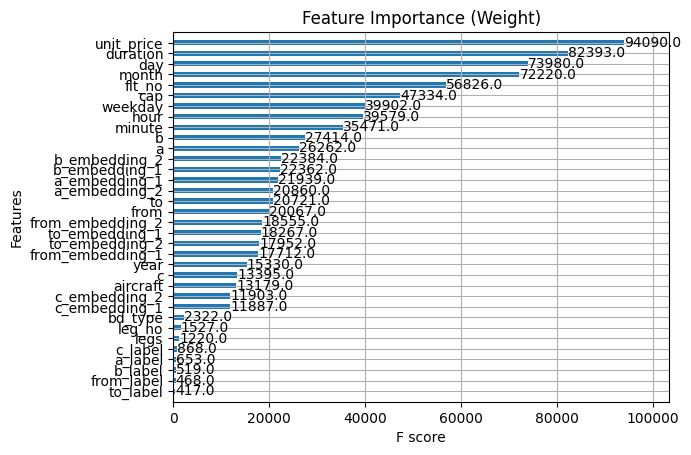

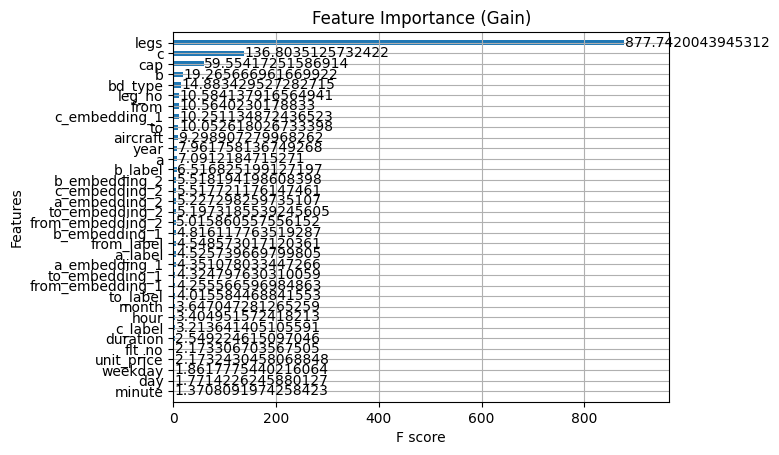

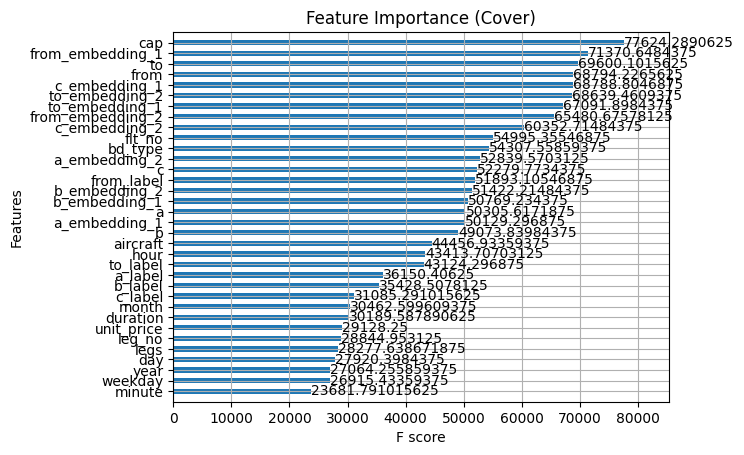

In [23]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 假设 model 是训练好的 XGBoost 模型
xgb.plot_importance(model, importance_type='weight', title="Feature Importance (Weight)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='gain', title="Feature Importance (Gain)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='cover', title="Feature Importance (Cover)", height=0.5)
plt.show()